# MCDI505 — Análisis de Series de Tiempo
## Sumativa 1 — Informe de análisis exploratorio de la serie de consumo eléctrico comercial

| | |
|---|---|
| **Estudiante** | Claudio Rodolfo Alarcón Pradenas |
| **Programa** | Magíster en Ciencia de Datos e Inteligencia Artificial, Universidad Andrés Bello |
| **Docente** | Dr. Harvey Jezlid Rosas Quintero |
| **Evaluación** | Sumativa 1 · Semana 1 · Fase 1 (definición y orientación de la situación) |
| **Fecha** | 4 de octubre de 2026 |
| **Datos** | `consumo_electrico_litoral.csv` (caso transversal del curso) |
| **Repositorio GitHub** | `https://github.com/claudioalarconP/Analisis_de_serie_de_tiempo` |

**Repositorio de respaldo y reproducibilidad:** contiene el dataset y los notebooks utilizados durante el desarrollo de la Semana 1.

## 1. Introducción y objetivo

**Contexto.** La Distribuidora Eléctrica del Litoral (DEL) abastece a comunas de la Región de Valparaíso. Su segmento comercial concentra cerca de un tercio de la energía distribuida y es el de mayor variabilidad estacional. Cada diciembre, DEL compromete los volúmenes mensuales de energía del año siguiente. Contratar de menos obliga a comprar en el mercado *spot* a precios entre 2 y 4 veces mayores, y contratar de más implica pagar energía no consumida (Universidad Andrés Bello [UNAB], s.f.-a).

**Datos.** La variable objetivo es `consumo_gwh`, la energía mensual facturada al segmento comercial (GWh). El archivo tiene 120 observaciones mensuales, de enero de 2015 a diciembre de 2024, y tres covariables: `clientes_comerciales`, `temperatura_media_c` y `dias_habiles`. Los datos son sintéticos y se tratan como un caso observado, sin conocer su proceso generador. Según el protocolo del caso, 2024 queda sellado para la Semana 4. La auditoría revisa las 120 filas; el resto del análisis usa 2015–2023 (108 meses).

**Objetivo.** Identificar la tendencia, la estacionalidad, el ciclo y el error de la serie, relacionarlos con la ACF y la PACF, y derivar implicancias para el modelamiento posterior.

## 2. Configuración y reproducibilidad

Se usan `pandas`, `numpy`, `matplotlib` y `statsmodels` (Seabold y Perktold, 2010). El CSV se busca con rutas relativas (junto al notebook o en `../../data/raw/`); en Google Colab, si no está, se pide subirlo. El archivo no se modifica: toda limpieza ocurre en memoria.

In [1]:
# --- Bibliotecas ---
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(505)          # semilla del curso (no hay procesos aleatorios en este análisis)
# --- Estilo común de los gráficos (paleta del material docente) ---
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 9, "axes.titlesize": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
ROJO, AZUL, GRIS = "#b30338", "#0057b8", "#9e9e9e"

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | "
      f"statsmodels {statsmodels.__version__}")

Python 3.12.5 | pandas 3.0.3 | statsmodels 0.14.6


## 3. Carga y auditoría del dataset

In [2]:
# --- Búsqueda del CSV con rutas relativas: junto al notebook o en la estructura del proyecto ---
ARCHIVO = "consumo_electrico_litoral.csv"
rutas = [Path(ARCHIVO), Path("../../data/raw") / ARCHIVO, Path("../data/raw") / ARCHIVO]

ruta = None
for r in rutas:
    if r.exists():
        ruta = r
        break

if ruta is None:                       # no está en disco: si es Colab, subirlo manualmente
    try:
        from google.colab import files
        files.upload()
        ruta = Path(ARCHIVO)
    except ImportError:                # no es Colab: se informa el error abajo
        pass
if ruta is None or not ruta.exists():
    raise FileNotFoundError(f"No se encontró '{ARCHIVO}'. Ubíquelo junto al notebook, "
                            "en ../../data/raw/ o súbalo al ejecutar en Google Colab.")

df = (
    pd.read_csv(ruta, parse_dates=["fecha"])
    .set_index("fecha")
    .asfreq("MS")                      # índice mensual (inicio de mes)
)

print("Archivo:", ruta)
print("Observaciones:", len(df))
print("Periodo:", df.index.min().date(), "a", df.index.max().date())

Archivo: ..\..\data\raw\consumo_electrico_litoral.csv
Observaciones: 120
Periodo: 2015-01-01 a 2024-12-01


In [3]:
# --- Auditoría de la estructura temporal (las 120 filas del archivo) ---
idx = df.index
calendario = pd.date_range(idx.min(), idx.max(), freq="MS")   # calendario mensual esperado
y_obs = df["consumo_gwh"]
auditoria = pd.Series({
    "observaciones": len(df),
    "inicio / fin": f"{idx.min():%Y-%m} / {idx.max():%Y-%m}",
    "frecuencia": idx.freqstr,
    "orden cronológico": idx.is_monotonic_increasing,
    "fechas duplicadas": int(idx.duplicated().sum()),
    "meses ausentes del calendario": len(calendario.difference(idx)),
    "fechas sin consumo_gwh": list(y_obs[y_obs.isna()].index.strftime("%Y-%m")),
    "valores no positivos": int((y_obs <= 0).sum()),
    "nulos en covariables": int(df.drop(columns="consumo_gwh").isna().sum().sum()),
    "tipos": ", ".join(f"{c}: {t}" for c, t in df.dtypes.astype(str).items()),
}, name="resultado")
display(auditoria.to_frame())

# --- Partición del caso: 2024 queda sellado como conjunto de prueba (Semana 4) ---
train = df.loc[:"2023-12-01"].copy()
print(f"Periodo analizado: {train.index.min():%Y-%m} a {train.index.max():%Y-%m} "
      f"({len(train)} meses). Periodo sellado: 2024 ({len(df) - len(train)} meses).")

,resultado
observaciones,120
inicio / fin,2015-01 / 2024-12
frecuencia,MS
orden cronológico,True
fechas duplicadas,0
meses ausentes del calendario,0
fechas sin consumo_gwh,"[2016-08, 2019-02, 2022-06]"
valores no positivos,0
nulos en covariables,0
tipos,"consumo_gwh: float64, clientes_comerciales: in..."


Periodo analizado: 2015-01 a 2023-12 (108 meses). Periodo sellado: 2024 (12 meses).


El índice es mensual (`MS`), ordenado, sin duplicados ni meses ausentes. Solo `consumo_gwh` tiene faltantes: tres meses sin registro (2016-08, 2019-02 y 2022-06), todos dentro del periodo de análisis. Un mes sin registro no equivale a consumo cero, así que se imputa en la sección 4.

## 4. Tratamiento mínimo de faltantes y anomalías

### 4.1 Valores faltantes

Los tres huecos no son equivalentes:

- **Agosto de 2016** está en la meseta invernal.
- **Febrero de 2019** cae en el descenso más pronunciado del año, después del máximo de enero.
- **Junio de 2022** está en el ascenso hacia el máximo invernal.

Se comparan las tres estrategias del notebook del caso. Para no elegir a ciegas, cada una se prueba sobre meses conocidos del mismo mes calendario, borrados de forma artificial.

In [4]:
# --- Comparación de estrategias de imputación para los tres huecos ---
s = train["consumo_gwh"]
huecos = s[s.isna()].index


def imputar(x):
    """Las tres estrategias del notebook del caso, aplicadas a la serie x."""
    return {"lineal": x.interpolate("linear"),
            "temporal": x.interpolate("time"),
            "estacional ajustada": x.fillna(x.shift(12) * (x.shift(1) / x.shift(13)))}


# (a) Vecinos observados y valor que propone cada estrategia
valores = pd.DataFrame({"mes anterior": s.shift(1)[huecos], "mes siguiente": s.shift(-1)[huecos]})
for k, v in imputar(s).items():
    valores[k] = v[huecos]
display(valores.round(2))

# (b) Huecos simulados: se borra cada valor conocido del MISMO mes calendario y se mide
#     el error absoluto de cada estrategia al reconstruirlo. Se excluyen 2015 (sin año
#     previo), el periodo COVID y noviembre de 2017 (atípico).
excluir = pd.date_range("2020-03-01", "2021-12-01", freq="MS").append(
    pd.DatetimeIndex(["2017-11-01"]))
errores = {}
for h in huecos:
    meses = s.index[(s.index.month == h.month) & s.notna() & (s.index.year > 2015)
                    & ~s.index.isin(excluir)]
    err = {k: [] for k in imputar(s)}
    for d in meses:
        x = s.copy()
        x[d] = np.nan                                    # hueco simulado
        for k, v in imputar(x).items():
            if pd.notna(v[d]):
                err[k].append(abs(v[d] - s[d]))
    errores[f"{h:%Y-%m} (n={len(meses)})"] = {k: np.mean(e) for k, e in err.items()}
print("Error absoluto medio (GWh) al reconstruir meses conocidos del mismo mes:")
display(pd.DataFrame(errores).T.round(2))

,mes anterior,mes siguiente,lineal,temporal,estacional ajustada
fecha,,,,,
2016-08-01,98.28,93.44,95.86,95.86,94.87
2019-02-01,128.36,105.49,116.93,116.34,114.18
2022-06-01,99.24,103.55,101.40,101.43,103.86


Error absoluto medio (GWh) al reconstruir meses conocidos del mismo mes:


,lineal,temporal,estacional ajustada
2016-08 (n=5),2.84,2.84,4.13
2019-02 (n=6),3.60,3.53,7.20
2022-06 (n=5),1.17,1.12,3.31


| Elemento | Decisión 4.1 |
|---|---|
| **Decisión** | Interpolación lineal en los tres huecos: 95,86 GWh (2016-08), 116,93 GWh (2019-02) y 101,40 GWh (2022-06). |
| **Evidencia** | Es la de menor error en los huecos simulados (2,84; 3,60 y 1,17 GWh, frente a 4,13; 7,20 y 3,31 GWh de la imputación estacional). La imputación estacional arrastra el ruido del año anterior. |
| **Alternativa descartada** | Interpolación temporal. Da casi lo mismo (diferencia < 0,1 GWh), pero pondera por días calendario, algo que no tiene sentido para un total mensual con índice equiespaciado. |
| **Consecuencia** | Febrero de 2019 es el hueco más incierto (≈ 3,6 GWh de error esperado). Interpolar puede inflar levemente la autocorrelación de rezago 1, pero afecta solo a 3 de 108 meses (2,8 %). |

### 4.2 Atípico de noviembre de 2017

El área de operaciones informó una recalibración de medidores en noviembre de 2017 (UNAB, s.f.-a). Antes de tratarlo, se verifica con el procedimiento del notebook del caso: un *z* robusto (mediana y MAD) del componente irregular.

In [5]:
# --- z robusto del componente irregular (procedimiento del notebook del caso) ---
s_lin = s.interpolate("linear")                        # serie provisional sin huecos
nivel = s_lin.rolling(12, center=True).mean().rolling(2, center=True).mean().shift(-1)
razon = (s_lin / nivel).dropna()                       # estacionalidad + irregular
irregular = razon / razon.groupby(razon.index.month).transform("median")  # sin efecto mes
mad = (irregular - irregular.median()).abs().median()
z = (irregular - irregular.median()) / (1.4826 * mad)
print("Meses con |z| > 3,5:", {f"{d:%Y-%m}": round(v, 2) for d, v in z[z.abs() > 3.5].items()})

# Evidencia específica de noviembre de 2017
yoy = 100 * (s_lin / s_lin.shift(12) - 1)
resto = yoy.drop(excluir).dropna()                     # sin COVID ni 2017-11
nov_dic = {a: round(float(s_lin[f"{a}-11-01"] / s_lin[f"{a}-12-01"]), 3)
           for a in range(2015, 2024)}
print(f"Var. interanual 2017-11: {yoy['2017-11-01']:+.1f} % (resto: media {resto.mean():.1f} %, "
      f"desv. est. {resto.std():.1f}, máximo {resto.max():.1f} %)")
print("Razón noviembre/diciembre por año:", nov_dic)

# --- Serie de trabajo: el atípico se trata como faltante y se imputa como los huecos ---
y = s.copy()
y["2017-11-01"] = np.nan                  # recalibración de medidores: no es consumo real
y = y.interpolate("linear")               # decisión de la sección 4.1
efecto = pd.DataFrame({
    "con el atípico": [s_lin.mean(), s_lin.std(), *acf(s_lin, nlags=12)[[1, 12]]],
    "atípico ajustado": [y.mean(), y.std(), *acf(y, nlags=12)[[1, 12]]],
}, index=["media (GWh)", "desv. estándar (GWh)", "ACF rezago 1", "ACF rezago 12"])
print(f"2017-11: {s['2017-11-01']:.2f} GWh registrado → {y['2017-11-01']:.2f} GWh ajustado")
display(efecto.round(3).T)

Meses con |z| > 3,5: {'2017-11': 4.05, '2019-10': 3.51, '2020-02': 3.64, '2020-04': -5.2, '2020-05': -7.46, '2020-06': -5.19}
Var. interanual 2017-11: +13.8 % (resto: media 4.5 %, desv. est. 4.4, máximo 13.5 %)
Razón noviembre/diciembre por año: {2015: 0.857, 2016: 0.885, 2017: 0.992, 2018: 0.958, 2019: 0.889, 2020: 0.839, 2021: 0.874, 2022: 0.911, 2023: 0.894}
2017-11: 118.96 GWh registrado → 107.85 GWh ajustado


,media (GWh),desv. estándar (GWh),ACF rezago 1,ACF rezago 12
con el atípico,102.900,12.583,0.745,0.652
atípico ajustado,102.797,12.495,0.748,0.650


Noviembre de 2017 es el único candidato con |*z*| > 3,5 fuera del periodo COVID (*z* = 4,05). Los meses 2019-10 y 2020-02 también superan el umbral, pero es un efecto del método: su media móvil incluye la caída de 2020. Su variación interanual (+13,8 %) es alta, aunque no única. La prueba más clara es la razón noviembre/diciembre: 0,992, frente a 0,839–0,958 en los demás años.

| Elemento | Decisión 4.2 |
|---|---|
| **Decisión** | Ajustar: tratar 2017-11 como faltante e interpolarlo (118,96 → 107,85 GWh). La columna original se conserva en `df`. |
| **Evidencia** | *z* = 4,05, razón noviembre/diciembre fuera de rango y causa documentada: no es consumo real. |
| **Alternativa descartada** | Conservarlo, porque contamina el factor estacional de noviembre. Una variable indicadora serviría en las semanas 3–4, pero no corrige la descomposición ni la ACF. |
| **Consecuencia** | El efecto global es pequeño (media 102,90 → 102,80 GWh; ACF(1) 0,745 → 0,748). El efecto relevante es local, en el patrón de noviembre. |

## 5. Exploración y visualización

### 5.1 Serie temporal, cambios de nivel y shock COVID-19

La variación interanual (Figura 1, abajo) compara cada mes con el mismo mes del año anterior. Así elimina la estacionalidad y deja ver los cambios de nivel.

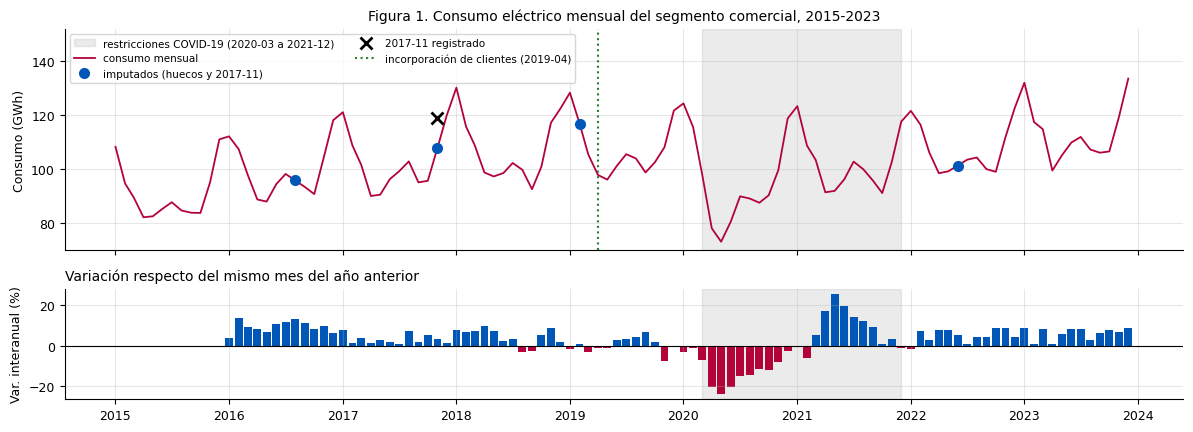

Mayor caída interanual: 2020-05 (-23.9 %); 2020-03 a 2020-06: [-6.9, -20.2, -23.9, -20.4]
Var. interanual 2021-04 a 2021-07 (efecto base): [17.1, 25.7, 19.5, 14.3]
Nivel vs. mismo mes de 2019 → 2021: -11.1 % a -1.9 %; 2022: -5.2 % a +3.4 %
Clientes: alza 2019-03 → 2019-04 = +1059 (mediana mensual 120)


In [6]:
# --- Figura 1: serie mensual, eventos del periodo y variación interanual ---
covid = (pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"))
nov17 = pd.Timestamp("2017-11-01")
var_ia = 100 * (y / y.shift(12) - 1)          # vs. el mismo mes del año anterior

fig, axes = plt.subplots(2, 1, figsize=(12, 4.4), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.axvspan(*covid, color=GRIS, alpha=0.2, label="restricciones COVID-19 (2020-03 a 2021-12)")
ax.plot(y.index, y, color=ROJO, lw=1.3, label="consumo mensual")
imputados = huecos.append(pd.DatetimeIndex([nov17]))
ax.plot(imputados, y[imputados], "o", color=AZUL, ms=7, label="imputados (huecos y 2017-11)")
ax.plot([nov17], [s[nov17]], "x", color="k", ms=9, mew=2, label="2017-11 registrado")
ax.axvline(pd.Timestamp("2019-04-01"), color="#2e7d32", ls=":", lw=1.5,
           label="incorporación de clientes (2019-04)")
ax.set_ylim(70, 152)                                 # espacio superior para la leyenda
ax.set_ylabel("Consumo (GWh)")
ax.set_title("Figura 1. Consumo eléctrico mensual del segmento comercial, 2015-2023")
ax.legend(fontsize=7.5, ncol=2, loc="upper left")

axes[1].axvspan(*covid, color=GRIS, alpha=0.2)
axes[1].bar(var_ia.index, var_ia, width=25, color=np.where(var_ia < 0, ROJO, AZUL))
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylabel("Var. interanual (%)")
axes[1].set_title("Variación respecto del mismo mes del año anterior", loc="left")
plt.tight_layout()
plt.show()

# --- Cifras que delimitan el shock y los cambios de nivel ---
vs19 = pd.Series({d: 100 * (y[d] / y[f"2019-{d.month:02d}-01"] - 1)
                  for d in y["2021":"2022"].index})
print(f"Mayor caída interanual: {var_ia.idxmin():%Y-%m} ({var_ia.min():+.1f} %); "
      f"2020-03 a 2020-06: {var_ia['2020-03':'2020-06'].round(1).tolist()}")
print("Var. interanual 2021-04 a 2021-07 (efecto base):",
      var_ia["2021-04":"2021-07"].round(1).tolist())
print(f"Nivel vs. mismo mes de 2019 → 2021: {vs19['2021'].min():+.1f} % a "
      f"{vs19['2021'].max():+.1f} %; 2022: {vs19['2022'].min():+.1f} % a "
      f"{vs19['2022'].max():+.1f} %")
dc = train["clientes_comerciales"].diff()
print(f"Clientes: alza 2019-03 → 2019-04 = {dc['2019-04-01']:+.0f} "
      f"(mediana mensual {dc.median():.0f})")

**Tendencia.** El nivel crece entre 2015 y 2018, con medias anuales de 90,8 a 107,1 GWh. Se estanca en 2019 (107,3 GWh), cae en 2020 (95,5 GWh) y llega a 113,7 GWh en 2023. La tendencia es creciente, pero no lineal.

**Shock COVID-19.**

- **Inicio y fondo.** La caída se profundiza desde marzo de 2020 (−6,9 % interanual) y toca fondo en mayo (−23,9 %).
- **Efecto base.** Entre abril y julio de 2021 aparecen alzas de +14,3 % a +25,7 %. No son crecimiento real: esos meses se comparan con los meses deprimidos de 2020.
- **Recuperación.** Frente a 2019, el consumo de 2021 sigue entre 11,1 % y 1,9 % por debajo. Solo en 2022 vuelve a oscilar en torno al nivel previo (−5,2 % a +3,4 %).

Se adopta como ventana **marzo de 2020 a diciembre de 2021**, coherente con los antecedentes del caso. Es un **shock exógeno temporal**, no un ciclo.

**Cambio de nivel de 2019.** En abril de 2019 los clientes aumentan en 1.059 en un mes (la mediana mensual es 120). Aun así, el consumo no muestra un escalón: no hay un quiebre identificable en la serie objetivo.

### 5.2 Estacionalidad y doble máximo anual

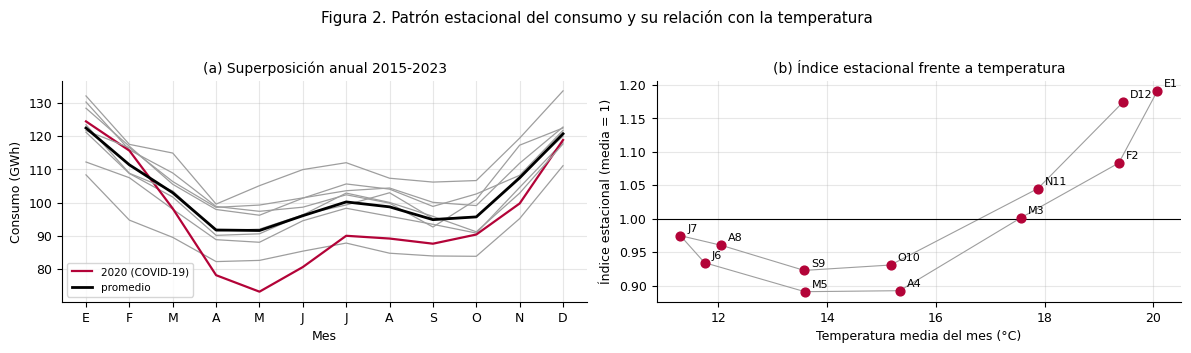

,E,F,M,A,M,J,J,A,S,O,N,D
índice estacional,1.191,1.083,1.001,0.892,0.891,0.934,0.975,0.96,0.923,0.931,1.045,1.174
temperatura (°C),20.100,19.400,17.600,15.300,13.600,11.700,11.300,12.10,13.600,15.200,17.900,19.400


Mes del máximo anual: {2015: 12, 2016: 12, 2017: 1, 2018: 1, 2019: 1, 2020: 1, 2021: 1, 2022: 12, 2023: 12}
Mes del máximo invernal: {2015: 7, 2016: 7, 2017: 8, 2018: 7, 2019: 7, 2020: 7, 2021: 7, 2022: 8, 2023: 7}


In [7]:
# --- Figura 2: patrón estacional y relación con la temperatura media ---
perfil = y.groupby(y.index.month).mean() / y.mean()      # índice estacional (media = 1)
temp_mes = train["temperatura_media_c"].groupby(train.index.month).mean()
meses = ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for anio, g in y.groupby(y.index.year):                   # un trazo por año
    es2020 = anio == 2020
    axes[0].plot(g.index.month, g.values, color=ROJO if es2020 else GRIS,
                 lw=1.6 if es2020 else 0.9, label="2020 (COVID-19)" if es2020 else None)
axes[0].plot(range(1, 13), y.groupby(y.index.month).mean(), "k", lw=2, label="promedio")
axes[0].set_xticks(range(1, 13), meses)
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Consumo (GWh)")
axes[0].set_title("(a) Superposición anual 2015-2023")
axes[0].legend(fontsize=7.5)

axes[1].plot(temp_mes, perfil, "-", color=GRIS, lw=0.8)    # recorrido enero → diciembre
axes[1].scatter(temp_mes, perfil, color=ROJO, s=40, zorder=3)
for m in range(1, 13):
    axes[1].annotate(f"{meses[m - 1]}{m}", (temp_mes[m], perfil[m]),
                     textcoords="offset points", xytext=(5, 3), fontsize=8)
axes[1].axhline(1, color="k", lw=0.8)
axes[1].set_xlabel("Temperatura media del mes (°C)")
axes[1].set_ylabel("Índice estacional (media = 1)")
axes[1].set_title("(b) Índice estacional frente a temperatura")
fig.suptitle("Figura 2. Patrón estacional del consumo y su relación con la temperatura", y=1.02)
plt.tight_layout()
plt.show()

tabla = pd.DataFrame({"índice estacional": perfil.round(3),
                      "temperatura (°C)": temp_mes.round(1)})
display(tabla.T.set_axis(meses, axis=1))
invierno = y[y.index.month.isin(range(5, 10))]             # mayo a septiembre
print("Mes del máximo anual:", y.groupby(y.index.year).idxmax().dt.month.to_dict())
print("Mes del máximo invernal:",
      invierno.groupby(invierno.index.year).idxmax().dt.month.to_dict())

**Estacionalidad.** Todos los años repiten la misma forma (Figura 2a):

- máximo en verano (enero o diciembre, en los nueve años);
- mínimo en abril–mayo;
- **segundo máximo en invierno** (julio en siete años, agosto en dos);
- segundo mínimo en septiembre–octubre.

El índice estacional va de 0,891 (mayo) a 1,191 (enero). En 2020 se mantiene la forma, desplazada hacia abajo: el shock afectó el nivel, no el calendario.

**Temperatura.** La relación tiene forma de U (Figura 2b). El consumo es mínimo en los meses templados (13,6–15,3 °C) y sube en ambos extremos: enero (20,1 °C) y julio (11,3 °C). Esto es compatible con climatización en verano y calefacción e iluminación en invierno. Por esa forma, una correlación lineal subestimaría el efecto, y la temperatura acompaña el patrón sin probar por sí sola el mecanismo.

### 5.3 ¿La amplitud estacional crece con el nivel?

Si el esquema es multiplicativo, la amplitud absoluta acompaña al nivel y la relativa se mantiene estable.

In [8]:
# --- ¿Esquema aditivo o multiplicativo? Amplitud estacional año a año ---
anual = y.groupby(y.index.year)
amp = pd.DataFrame({"media (GWh)": anual.mean(),
                    "amplitud máx-mín (GWh)": anual.max() - anual.min(),
                    "desv. est. (GWh)": anual.std()})
amp["amplitud relativa (%)"] = 100 * amp["amplitud máx-mín (GWh)"] / amp["media (GWh)"]
amp["coef. variación (%)"] = 100 * amp["desv. est. (GWh)"] / amp["media (GWh)"]
display(amp.round(2).T)

n_ = amp.drop(index=[2020, 2021])                         # años sin el shock
cambio = lambda c: 100 * (n_[c].iloc[-1] / n_[c].iloc[0] - 1)
print(f"Sin 2020-2021: media {cambio('media (GWh)'):+.0f} %, amplitud absoluta "
      f"{cambio('amplitud máx-mín (GWh)'):+.0f} %, amplitud relativa "
      f"{n_['amplitud relativa (%)'].mean():.1f} % ± {n_['amplitud relativa (%)'].std():.1f}")

fecha,2015,2016,2017,2018,2019,2020,2021,2022,2023
media (GWh),90.78,99.18,102.46,107.09,107.26,95.49,102.15,107.10,113.66
amplitud máx-mín (GWh),28.84,30.11,31.01,37.59,32.18,51.21,32.19,24.16,34.05
desv. est. (GWh),9.84,9.51,10.28,11.72,10.02,16.48,10.24,8.88,10.54
amplitud relativa (%),31.77,30.36,30.26,35.10,30.00,53.63,31.51,22.56,29.96
coef. variación (%),10.84,9.59,10.04,10.95,9.34,17.26,10.02,8.29,9.27


Sin 2020-2021: media +25 %, amplitud absoluta +18 %, amplitud relativa 30.0 % ± 3.8


Sin 2020–2021, la media anual sube 25 % y la amplitud absoluta 18 % (de 28,84 a 34,05 GWh), mientras la relativa se mantiene en torno a 30 % (± 3,8 puntos). La evidencia favorece moderadamente el **esquema multiplicativo**: la oscilación es proporcional al tamaño del segmento. Como el nivel varía poco, la diferencia práctica con el aditivo es acotada. En cuanto a la varianza, fuera de 2020 la desviación estándar anual se mantiene entre 8,88 y 11,72 GWh, sin un aumento sostenido. El año 2020 presenta una variabilidad excepcionalmente mayor (16,48 GWh; amplitud relativa de 53,63 %), asociada al shock temporal.

## 6. Descomposición de la serie

Se aplica STL (Cleveland et al., 1990) al **logaritmo** del consumo, con periodo 12:

1. El logaritmo convierte la estacionalidad multiplicativa en aditiva (log *y* = *T* + *S* + *R*). Al volver con la exponencial, la tendencia queda en GWh y la estacionalidad como factor (1,20 = +20 %).
2. `robust=True` reduce el peso de los extremos, de modo que el shock no deforme la tendencia ni la estacionalidad. La descomposición clásica, en cambio, promedia 2020 en los factores.
3. STL cubre los 108 meses; la clásica pierde seis meses en cada extremo.

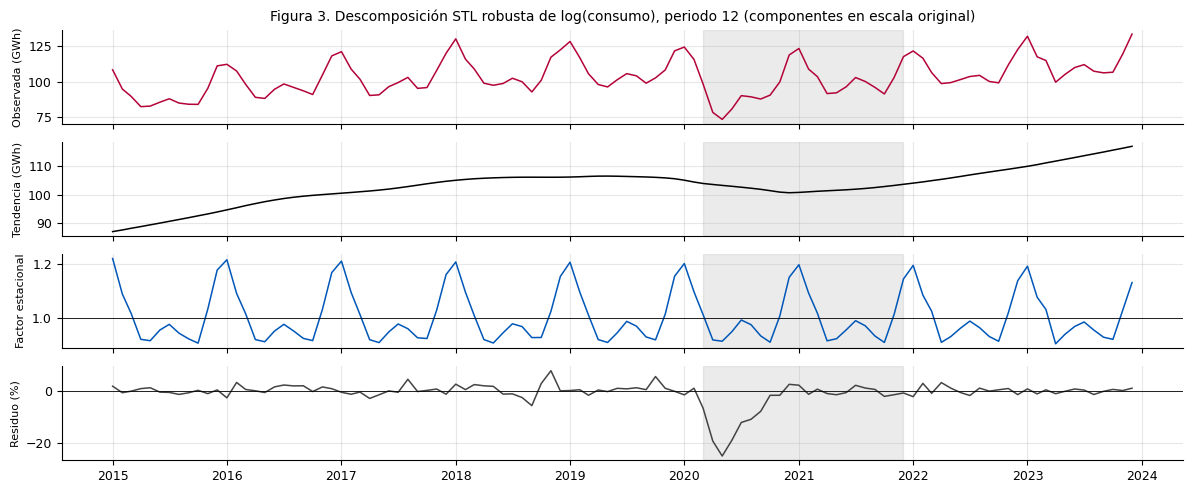

Tendencia, promedio anual (GWh): {2015: 90.4, 2016: 98.0, 2017: 102.4, 2018: 105.8, 2019: 106.2, 2020: 102.7, 2021: 102.0, 2022: 106.6, 2023: 113.3}
Tendencia: máximo previo 106.5 (2019-05) → mínimo 100.7 (2020-12), -5.5 %


,E,F,M,A,M,J,J,A,S,O,N,D
2015,1.222,1.089,1.016,0.918,0.913,0.953,0.975,0.941,0.920,0.904,1.032,1.179
2019,1.209,1.096,1.009,0.917,0.906,0.943,0.986,0.968,0.927,0.916,1.013,1.156
2023,1.193,1.077,1.031,0.901,0.937,0.967,0.984,0.953,0.926,0.918,1.027,1.132


Residuo: desv. est. 4.3 % (total) | 1.8 % (sin COVID)


fecha,2018-09,2018-11,2019-10,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09
residuo (%),-5.75,7.67,5.42,-6.73,-19.37,-25.09,-19.02,-12.2,-11.0,-7.93
peso robusto,0.07,0.00,0.12,0.00,0.00,0.00,0.00,0.0,0.0,0.00


Fuerza de la estacionalidad: 0.84 | de la tendencia: 0.67


In [9]:
# --- Descomposición STL robusta del logaritmo (esquema multiplicativo, s = 12) ---
stl = STL(np.log(y), period=12, robust=True).fit()   # robust: menor peso a extremos
tendencia = np.exp(stl.trend)                        # en GWh
factor_est = np.exp(stl.seasonal)                    # factor multiplicativo (1,20 = +20 %)
residuo = stl.resid                                  # log-residuo ≈ desviación proporcional

fig, axes = plt.subplots(4, 1, figsize=(12, 5.0), sharex=True)
paneles = [(y, "Observada (GWh)", ROJO), (tendencia, "Tendencia (GWh)", "k"),
           (factor_est, "Factor estacional", AZUL), (100 * residuo, "Residuo (%)", "#444444")]
for ax, (serie, titulo, color) in zip(axes, paneles):
    ax.axvspan(*covid, color=GRIS, alpha=0.2)
    ax.plot(serie.index, serie, color=color, lw=1.1)
    ax.set_ylabel(titulo, fontsize=8)
axes[2].axhline(1, color="k", lw=0.6)
axes[3].axhline(0, color="k", lw=0.6)
axes[0].set_title("Figura 3. Descomposición STL robusta de log(consumo), periodo 12 "
                  "(componentes en escala original)")
plt.tight_layout()
plt.show()

# --- Resumen numérico de los componentes ---
print("Tendencia, promedio anual (GWh):",
      tendencia.groupby(tendencia.index.year).mean().round(1).to_dict())
previo, covid_t = tendencia[:"2020-02"], tendencia["2020":"2021"]
print(f"Tendencia: máximo previo {previo.max():.1f} ({previo.idxmax():%Y-%m}) → "
      f"mínimo {covid_t.min():.1f} ({covid_t.idxmin():%Y-%m}), "
      f"{100 * (covid_t.min() / previo.max() - 1):+.1f} %")
display(pd.DataFrame({a: factor_est[str(a)].values for a in (2015, 2019, 2023)},
                     index=meses).T.round(3))
sin_covid = residuo.drop(pd.date_range(*covid, freq="MS"))
print(f"Residuo: desv. est. {100 * residuo.std():.1f} % (total) | "
      f"{100 * sin_covid.std():.1f} % (sin COVID)")
grandes = 100 * residuo[residuo.abs() > 0.05]                  # |residuo| > 5 %
display(pd.DataFrame({"residuo (%)": grandes, "peso robusto": stl.weights[grandes.index]})
        .rename(lambda d: f"{d:%Y-%m}").round(2).T)
fuerza = lambda c: max(0, 1 - residuo.var() / (c + residuo).var())  # Hyndman y Athanasopoulos
print(f"Fuerza de la estacionalidad: {fuerza(stl.seasonal):.2f} | "
      f"de la tendencia: {fuerza(stl.trend):.2f}")

**Tendencia.** Sube de 90,4 GWh (promedio de 2015) a 105,8 GWh (2018) y se aplana en 2019. Baja hasta 100,7 GWh en diciembre de 2020 y alcanza 113,3 GWh en 2023. Gracias al ajuste robusto, el shock no se absorbe en ella: cae 5,5 % desde su máximo previo, mientras la serie cae hasta 24 %. Su fuerza es 0,67 (Hyndman y Athanasopoulos, 2021).

**Estacionalidad.** Es el componente dominante (fuerza 0,84) y reproduce el doble máximo. En 2015, enero está 22 % sobre el nivel, julio 2,5 % bajo él y los mínimos entre 8 % y 10 % bajo él. El patrón es estable, con una leve atenuación del máximo de verano (enero: 1,222 → 1,193 entre 2015 y 2023).

**Ciclo.** Un ciclo es una oscilación de periodo variable, no ligada al calendario y de varios años (Hyndman y Athanasopoulos, 2021; UNAB, s.f.-b). En nueve años solo hay un estancamiento (2019) y una caída con causa conocida (2020), sin repeticiones. **El ciclo no es identificable**: la tendencia STL debe leerse como tendencia-ciclo.

**Residuo.** Su desviación estándar es 4,3 % en toda la serie y 1,8 % fuera del COVID, así que el error ordinario es pequeño. Concentra el shock (−25,1 % en mayo de 2020), con peso robusto casi nulo entre marzo y septiembre de 2020. Fuera de ese periodo, solo 2018-09, 2018-11 y 2019-10 superan el 5 %; no tienen causa documentada y se conservan.

| Fenómeno | Clasificación | Evidencia |
|---|---|---|
| Patrón anual con máximos en enero y julio | **Estacionalidad** (periodo fijo de 12) | Figuras 2 y 3 |
| Crecimiento 2015–2018 y 2021–2023 | **Tendencia** | Tendencia STL |
| Caída 2020-03 a 2021-12 | **Shock exógeno temporal** | Residuo de hasta −25 % |
| Clientes +1.059 (2019-04) | Cambio de nivel **sin quiebre** en consumo | Tendencia sin escalón |
| Noviembre de 2017 | **Atípico puntual** (ajustado) | *z* = 4,05; causa documentada |
| Oscilación de periodo variable | **Ciclo no identificable** | Sin repeticiones en nueve años |

## 7. Análisis de autocorrelación (ACF y PACF)

La guía de lectura de correlogramas supone estacionariedad (Box et al., 2015; UNAB, s.f.-b), algo que esta serie, con tendencia y estacionalidad marcadas, difícilmente cumple. Por eso se analizan dos versiones:

- la **serie original**;
- la **serie desestacionalizada** (log *y* − *S*), que separa la persistencia del nivel de la estacionalidad.

Se usan 36 rezagos, con las mismas bandas de los gráficos: Bartlett para la ACF y ±1,96/√*n* para la PACF.

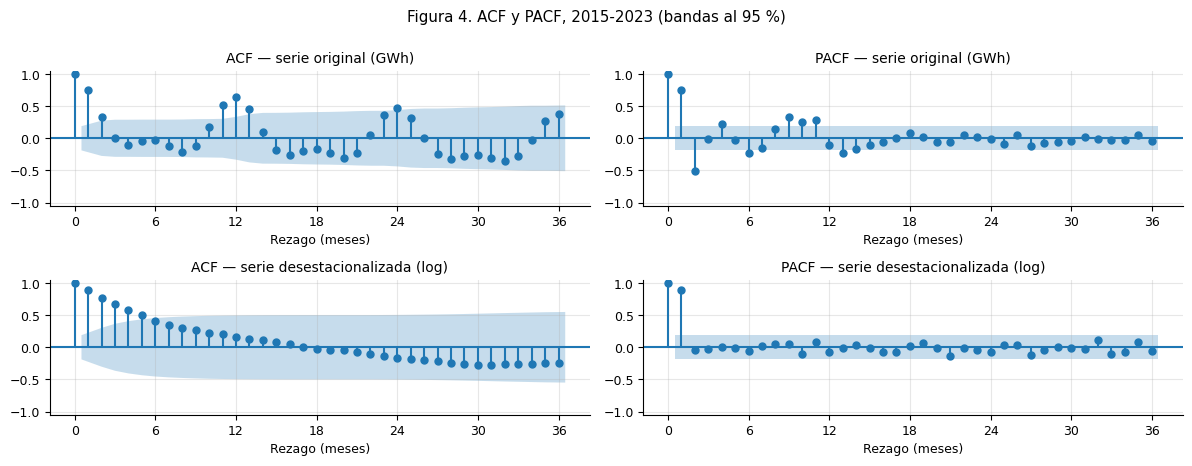

In [10]:
# --- Figura 4: ACF y PACF de la serie original y de la serie desestacionalizada ---
N_LAGS = 36                                         # tres años de rezagos (s = 12)
desest = np.log(y) - stl.seasonal                   # log-serie sin componente estacional
series_acf = {"serie original (GWh)": y, "serie desestacionalizada (log)": desest}

fig, axes = plt.subplots(2, 2, figsize=(12, 4.6))
for fila, (nombre, serie) in enumerate(series_acf.items()):
    plot_acf(serie, lags=N_LAGS, alpha=0.05, ax=axes[fila, 0], title=f"ACF — {nombre}")
    plot_pacf(serie, lags=N_LAGS, alpha=0.05, method="ywm", ax=axes[fila, 1],
              title=f"PACF — {nombre}")
    for ax in axes[fila]:
        ax.set_xticks(range(0, N_LAGS + 1, 6))
        ax.set_ylim(-1.05, 1.05)
        ax.set_xlabel("Rezago (meses)")
fig.suptitle("Figura 4. ACF y PACF, 2015-2023 (bandas al 95 %)", y=1.0)
plt.tight_layout()
plt.show()

In [11]:
# --- Valores y rezagos fuera de las MISMAS bandas que dibujan los gráficos ---
# ACF: banda de Bartlett 1,96·√[(1 + 2·Σ_{j<k} r_j²)/n], que crece con el rezago (plot_acf).
# PACF: banda ±1,96/√n (plot_pacf).
n = len(y)
rez = [1, 2, 3, 6, 11, 12, 13, 24, 36]
for nombre, serie in series_acf.items():
    r = acf(serie, nlags=N_LAGS)
    p = pacf(serie, nlags=N_LAGS, method="ywm")
    banda = 1.96 * np.sqrt(np.r_[np.nan, 1 + 2 * np.cumsum(np.r_[0, r[1:N_LAGS] ** 2])] / n)
    print(f"── {nombre}")
    display(pd.DataFrame({"ACF": r[rez], "banda ACF": banda[rez], "PACF": p[rez]},
                         index=rez).round(3).T)
    print("   ACF fuera de banda :",
          {k: round(float(r[k]), 3) for k in range(1, N_LAGS + 1) if abs(r[k]) > banda[k]})
    b_p = 1.96 / np.sqrt(n)
    print(f"   PACF fuera de banda (±{b_p:.3f}):",
          {k: round(float(p[k]), 3) for k in range(1, N_LAGS + 1) if abs(p[k]) > b_p})

# Dependencia que queda en el residuo STL, con y sin el episodio COVID
pre = residuo[:"2020-02"]
print(f"\nResiduo STL, ACF rezago 1: {acf(residuo, nlags=1)[1]:.3f} (2015-2023) | "
      f"{acf(pre, nlags=1)[1]:.3f} (2015-01 a 2020-02; banda ±{1.96 / np.sqrt(len(pre)):.3f})")

── serie original (GWh)


,1,2,3,6,11,12,13,24,36
ACF,0.748,0.337,-0.002,-0.021,0.523,0.650,0.460,0.476,0.376
banda ACF,0.189,0.275,0.289,0.291,0.302,0.333,0.376,0.438,0.512
PACF,0.748,-0.507,-0.006,-0.236,0.285,-0.105,-0.233,-0.004,-0.038


   ACF fuera de banda : {1: 0.748, 2: 0.337, 11: 0.523, 12: 0.65, 13: 0.46, 24: 0.476}
   PACF fuera de banda (±0.189): {1: 0.748, 2: -0.507, 4: 0.22, 6: -0.236, 9: 0.333, 10: 0.252, 11: 0.285, 13: -0.233}
── serie desestacionalizada (log)


,1,2,3,6,11,12,13,24,36
ACF,0.885,0.773,0.669,0.416,0.201,0.164,0.130,-0.164,-0.243
banda ACF,0.189,0.302,0.366,0.455,0.494,0.497,0.499,0.504,0.550
PACF,0.885,-0.050,-0.026,-0.065,0.081,-0.076,-0.016,-0.079,-0.059


   ACF fuera de banda : {1: 0.885, 2: 0.773, 3: 0.669, 4: 0.579, 5: 0.499}
   PACF fuera de banda (±0.189): {1: 0.885}

Residuo STL, ACF rezago 1: 0.758 (2015-2023) | 0.142 (2015-01 a 2020-02; banda ±0.249)


**Persistencia.** En los primeros rezagos, la ACF es alta en el rezago 1 (0,748), significativa en el 2 (0,337) y disminuye con rapidez antes de reaparecer la estructura estacional alrededor del rezago 12. En la serie original, la fuerte estructura estacional dificulta separar visualmente la persistencia asociada al nivel. Al retirar el componente estacional, la ACF presenta un decaimiento más lento.

**Estacionalidad.** Hay picos significativos en los rezagos 11, 12 y 13 (0,523; 0,650; 0,460) y en el 24 (0,476, sobre la banda de 0,438). El 36 (0,376) queda dentro de su banda (0,512). El lento decaimiento de los picos estacionales indica una estacionalidad persistente.

El rezago 6 es casi nulo (−0,021), un comportamiento consistente con la presencia de dos máximos separados aproximadamente por seis meses.

**PACF.** Destacan el rezago 1 (0,748) y el 2 (−0,507). El rezago 2 puede reflejar parte de la forma de la estructura estacional y no debe interpretarse directamente como evidencia de un modelo AR(2). También superan la banda los rezagos 4, 6, 9, 10, 11 y 13 (entre 0,22 y 0,33); la mayoría se agrupa en torno al rezago estacional. Como la serie conserva tendencia y estacionalidad, **esta PACF no sirve para elegir órdenes**.

**Dependencia del nivel.** Sin estacionalidad, la ACF decae lenta y casi linealmente (0,885; 0,773; 0,669; significativa hasta el rezago 5) y la PACF solo destaca en el rezago 1. Es un **comportamiento compatible con no estacionariedad en nivel**, asociado a la tendencia y al shock, y no necesariamente a un proceso autorregresivo. Su confirmación formal (ADF/KPSS) corresponde a la Semana 2. El residuo STL muestra además que gran parte de la autocorrelación residual se concentra durante el episodio COVID: su ACF(1) es 0,758 en toda la muestra, pero 0,142 antes del shock, dentro de la banda aproximada de ±0,249.

## 8. Interpretación técnica integrada

Las cuatro evidencias apuntan a lo mismo. La Figura 1 muestra un nivel creciente no lineal, interrumpido por un shock temporal. La Figura 2 y la sección 5.3 revelan una estacionalidad anual fija, con dos máximos ligados a los extremos de temperatura y amplitud proporcional al nivel. La descomposición cuantifica ese diagnóstico: la estacionalidad domina (fuerza 0,84) y es estable, la tendencia explica el largo plazo (0,67), el ciclo no es identificable y el error ordinario es pequeño (1,8 %).

La ACF es consistente con este diagnóstico desde la perspectiva de la dependencia temporal. Los picos en 12 y 24 corresponden a la estacionalidad, el rezago 6 casi nulo al doble máximo, y la persistencia del nivel aparece al desestacionalizar. La PACF, en cambio, todavía no permite identificar órdenes.

| Hallazgo | Implicancia para las semanas 2–4 |
|---|---|
| Estacionalidad persistente, *s* = 12 | Evaluar componente estacional y diferenciación estacional (*D* = 1) con ADF, KPSS y ACF en 12, 24 y 36. |
| Persistencia del nivel (posible no estacionariedad) | Evaluar diferenciación regular (*d* = 1), sin sobrediferenciar. |
| Amplitud proporcional al nivel | Evaluar transformación logarítmica antes de diferenciar (y el sesgo al retransformar). |
| Shock 2020-03 a 2021-12 | La diferencia estacional lo trasladará a 2021 (efecto base de la Figura 1); evaluar su tratamiento: variable indicadora o muestra acotada. |

## 9. Conclusiones

El consumo comercial de DEL combina una **estacionalidad anual multiplicativa con doble máximo**, estable y compatible con los extremos de temperatura, una **tendencia creciente no lineal** y un **shock temporal** por COVID-19 (marzo de 2020 a diciembre de 2021) que redujo el consumo hasta 24 %. No se identifica un ciclo y el error ordinario es pequeño. En la Semana 2 corresponde evaluar el logaritmo, las diferencias estacional y regular, y el tratamiento del shock antes de proponer órdenes para un modelo estacional con *s* = 12.

## 10. Limitaciones

- **Muestra.** Nueve años de datos sintéticos alcanzan para la estacionalidad, pero no para identificar ciclos.
- **Imputación.** La prueba de huecos simulados usa 5 o 6 meses por caso.
- **Sensibilidad.** La ventana COVID y la robustez de STL condicionan la separación entre tendencia y residuo.
- **Bandas y covariables.** Las bandas de ACF y PACF suponen ruido blanco. La relación con la temperatura es descriptiva; un SARIMAX con temperatura sería una extensión opcional, que exigiría pronosticarla. No se analizaron los días hábiles.

## 11. Referencias

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., y Ljung, G. M. (2015). *Time series analysis: Forecasting and control* (5.ª ed.). Wiley.

Cleveland, R. B., Cleveland, W. S., McRae, J. E., y Terpenning, I. (1990). STL: A seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics, 6*(1), 3–73.

Hyndman, R. J., y Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3.ª ed.). OTexts. https://otexts.com/fpp3/

Seabold, S., y Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. En S. van der Walt y J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011

Universidad Andrés Bello. (s.f.-a). *MCDI505 — Análisis de series de tiempo. Caso transversal del curso: Documento base* [Notebook de Jupyter, material docente del curso].

Universidad Andrés Bello. (s.f.-b). *MCDI505 — Sesión 1: Naturaleza de los datos temporales y autocorrelación* [Notebook de Jupyter, material docente del curso].

---
**Se utilizó un asistente de IA generativa como apoyo para organizar el informe, revisar el código y mejorar la redacción. Todos los resultados fueron obtenidos mediante la ejecución del notebook y revisados por mí. Las decisiones, interpretaciones y conclusiones fueron analizadas y verificadas personalmente a partir de los resultados y del material de la asignatura.